# Cellpose-derived corridor processing, publication schematic

This notebook produces the revised six-panel figure:

- **A:** full Cellpose input with a red ROI
- **B:** thresholded ROI
- **C:** the same physical ROI after rotation and cleanup
- **D:** the same rotated ROI after ignored accessible pixels are shown in black
- **E:** simplified full-surface corridor detection with a separate coverage profile
- **F:** local confinement-width extraction for a corridor segment overlapping the ROI

In [1]:
from pathlib import Path

SCRIPT_PATH = Path("corridor_processing_cellpose_exact_v6.py")

SURFACE = 1462

SETTINGS = {
    1462: {
        "cellpose_path": Path(r"..\cellpose flows 1462.tif"),
        "reference_path": Path(r"..\FixedPattern_16x16_1462_binary_filled.tif"),
        "invert_cellpose": True,
        "rotation_deg": 28.34,
        "surface_name": "TopoChip feature 1462",
    },
    1476: {
        "cellpose_path": Path(r"..\cellpose flows 1476.tif"),
        "reference_path": Path(r"..\FixedPattern_16x16_1476_binary_filled.tif"),
        "invert_cellpose": False,
        "rotation_deg": -13.47,
        "surface_name": "TopoChip feature 1476",
    },
}

cfg = SETTINGS[SURFACE]

CELLPOSE_IMAGE = cfg["cellpose_path"]
REFERENCE_IMAGE = cfg["reference_path"]
INVERT_CELLPOSE = cfg["invert_cellpose"]
ROTATION_DEG = cfg["rotation_deg"]
SURFACE_NAME = cfg["surface_name"]

PIXEL_SIZE_UM = 0.56
SCAN_STEP_PX = 1
ROW_COVERAGE_THRESHOLD = 0.07
MIN_ACCESSIBLE_COMPONENT_AREA = 16
MAX_FILLED_HOLE_AREA = 64
MERGE_GAP_PX = 3
MIN_BAND_HEIGHT = 5

# Use either ROI_PX or ROI_REL.
# ROI_PX = (x, y, width, height)
ROI_PX = None

# Smaller default ROI, approximately 5–6 repeats per direction.
# ROI_REL = (x_rel, y_rel, width_rel, height_rel)
ROI_REL = (0.20, 0.24, 0.25, 0.25)

# None automatically selects a corridor intersecting the ROI.
SELECTED_CORRIDOR_ID = None

# Maximum width of the local segment displayed in panel F.
MAX_LOCAL_WIDTH_PX = 220

OUTPUT_DIR = Path(f"cellpose_corridor_processing_{SURFACE}_v6")
SAVE_PDF = True
SAVE_SVG = True

print("Geometry input:", CELLPOSE_IMAGE)
print("Reference only:", REFERENCE_IMAGE)
print("Invert Cellpose:", INVERT_CELLPOSE)
print("Rotation:", ROTATION_DEG)
print("ROI_PX:", ROI_PX)
print("ROI_REL:", ROI_REL)

Geometry input: ..\cellpose flows 1462.tif
Reference only: ..\FixedPattern_16x16_1462_binary_filled.tif
Invert Cellpose: True
Rotation: 28.34
ROI_PX: None
ROI_REL: (0.2, 0.24, 0.25, 0.25)


In [2]:
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {SCRIPT_PATH.resolve()}\n"
        "Place the Python file beside this notebook or update SCRIPT_PATH."
    )

namespace = {
    "__name__": "corridor_processing_cellpose_exact_v6",
    "__file__": str(SCRIPT_PATH.resolve()),
}

exec(
    compile(
        SCRIPT_PATH.read_text(encoding="utf-8"),
        str(SCRIPT_PATH.resolve()),
        "exec",
    ),
    namespace,
)

process_cellpose_corridors = namespace["process_cellpose_corridors"]
create_exact_processing_schematic = namespace[
    "create_exact_processing_schematic"
]

print("Functions loaded successfully.")

Functions loaded successfully.


In [3]:
if not CELLPOSE_IMAGE.exists():
    raise FileNotFoundError(
        f"Cellpose input not found: {CELLPOSE_IMAGE.resolve()}"
    )

if REFERENCE_IMAGE.exists():
    REFERENCE_IMAGE_FOR_RUN = REFERENCE_IMAGE
else:
    REFERENCE_IMAGE_FOR_RUN = None
    print(
        "Reference image was not found. Processing can continue because the "
        "Cellpose image is the geometry source."
    )

print("Input paths checked.")

Input paths checked.


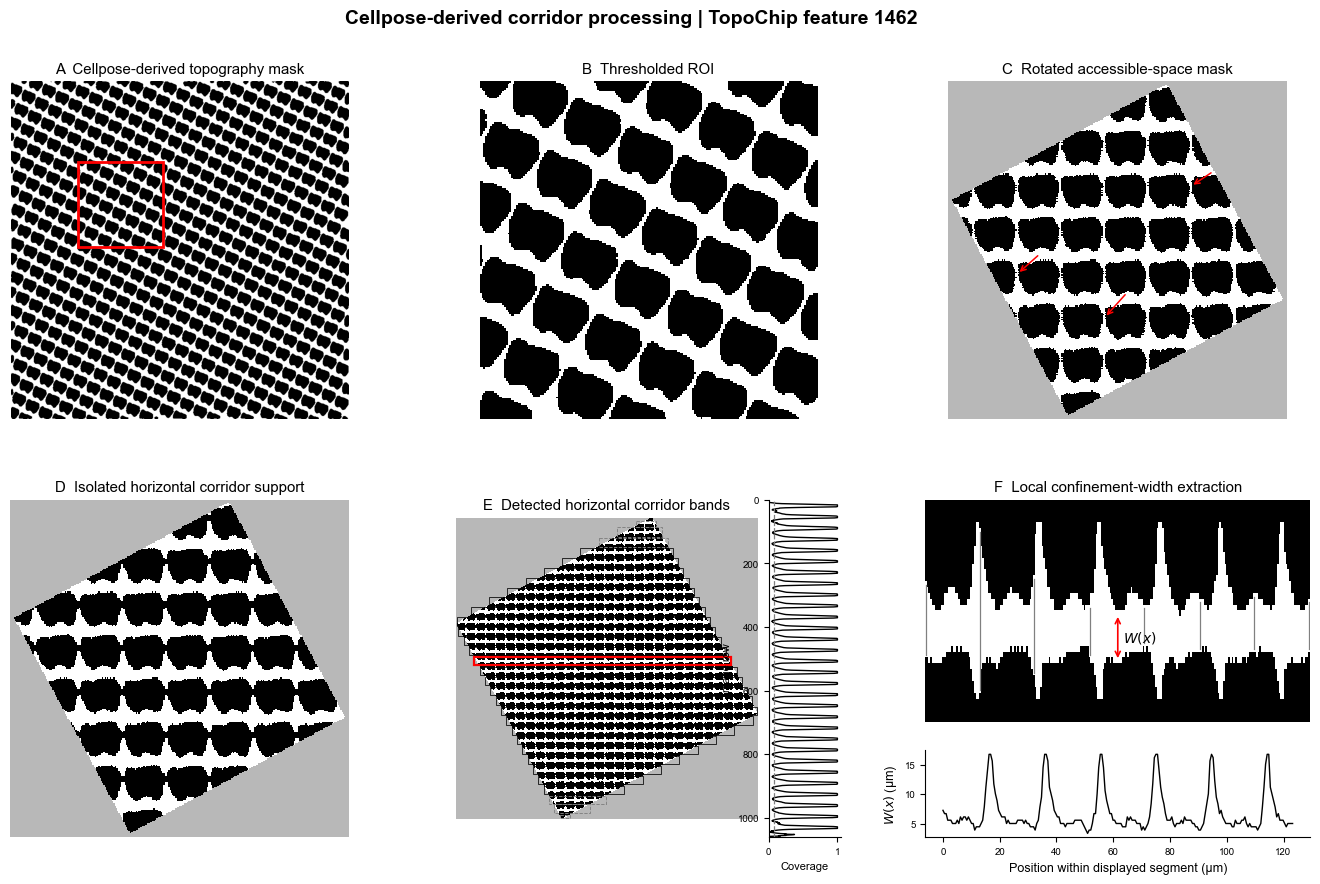

Detected bands: 31
Bands retained after outer 10% rule: 25
Selected corridor: 14
ROI in original image (x, y, w, h): (157, 188, 196, 196)
Displayed corridor segment: x=249 to x=469
Saved: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\cellpose_corridor_processing_1462_v6\cellpose_corridor_processing_schematic.png


In [4]:
result = process_cellpose_corridors(
    cellpose_image=CELLPOSE_IMAGE,
    reference_image=REFERENCE_IMAGE_FOR_RUN,
    invert_cellpose=INVERT_CELLPOSE,
    rotation_deg=ROTATION_DEG,
    row_cov_thresh_rel_hull=ROW_COVERAGE_THRESHOLD,
    tiny_white_px=MIN_ACCESSIBLE_COMPONENT_AREA,
    hole_area_threshold=MAX_FILLED_HOLE_AREA,
    merge_gap_px=MERGE_GAP_PX,
    min_band_height=MIN_BAND_HEIGHT,
    scan_step_px=SCAN_STEP_PX,
    pixel_size_um=PIXEL_SIZE_UM,
)

create_exact_processing_schematic(
    result=result,
    surface_name=SURFACE_NAME,
    output_dir=OUTPUT_DIR,
    selected_corridor_id=SELECTED_CORRIDOR_ID,
    save_pdf=SAVE_PDF,
    save_svg=SAVE_SVG,
    roi=ROI_PX,
    roi_rel=ROI_REL,
    max_local_width_px=MAX_LOCAL_WIDTH_PX,
)

In [ ]:
display(result["corridors"])

print(f"All detected bands: {len(result['corridors'])}")
print(
    "Retained after outer 10% positional rule:",
    int(result["corridors"]["used_for_width_profile"].sum()),
)
print(
    "Figure:",
    (OUTPUT_DIR / "cellpose_corridor_processing_schematic.png").resolve(),
)